In [1]:
import os

API_KEY      = "sk-or-v1-..."
RESULTS_DIR  = "/home/jovyan/solarchem-corpus-main/SolarChem-Evaluation/Task-3-LLM-performance/result-150/"                     
GROUND_TRUTH = "ground_truth.json"           
OUTPUT_DIR   = "figures/"                    


EMBED_MODEL = "qwen/qwen3-embedding-8b"
BASE_URL    = "https://openrouter.ai/api/v1"


CATEGORIES = ["catalyst", "co_catalyst", "light_source", "lamp",
              "reactor_type", "reaction_medium", "operation_mode"]
DISPLAY = {"catalyst": "Catalyst", "co_catalyst": "Co-Catalyst",
           "light_source": "Light Source", "lamp": "Lamp",
           "reactor_type": "Reactor Type", "reaction_medium": "Reaction Medium",
           "operation_mode": "Operation Mode"}

LOCAL_MODELS = {
    "google_gemma-4-26b-a4b-it", "google_gemma-4-31b-it",
    "qwen_qwen3.6-27b", "qwen_qwen3.6-35b-a3b",
}

In [2]:
import json, re, time
from pathlib import Path
from collections import defaultdict
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from thefuzz import fuzz
%matplotlib inline

def norm_cat(k):
    k = re.sub(r"[\s\-]+", "_", k.strip().lower())
    return k if k in CATEGORIES else None

def record_answers(rec):
    out = {}
    for k, v in rec.items():
        c = norm_cat(k)
        if c:
            out[c] = "" if v is None else str(v).strip()
    return out

def paper_id(fname):
    nums = re.findall(r"\d+", Path(fname).stem)
    return nums[-1] if nums else Path(fname).stem

def pretty(folder):
    return folder.split("_", 1)[1] if "_" in folder else folder

def is_local(folder):
    return folder in LOCAL_MODELS

def mean(xs):
    xs = [x for x in xs if x == x]       
    return sum(xs) / len(xs) if xs else float("nan")

def cosine(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(a @ b / (na * nb)) if na and nb else 0.0

/home/jovyan/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/jovyan/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
gt = {str(k): record_answers(v) for k, v in json.load(open(GROUND_TRUTH)).items()}
print(f"ground truth: {len(gt)} papers")

models = {}
for d in sorted(Path(RESULTS_DIR).iterdir()):
    if not d.is_dir():
        continue
    preds = {}
    for fp in d.glob("*.json"):
        try:
            preds[paper_id(fp.name)] = record_answers(json.load(open(fp)))
        except Exception as e:
            print(f"  ! skip {fp.name}: {e}")
    if preds:
        models[d.name] = preds
        print(f"  {d.name}: {len(preds)} files")

ground truth: 1096 papers
  deepseek_deepseek-v4-flash: 150 files
  deepseek_deepseek-v4-pro: 150 files
  google_gemma-4-26b-a4b-it: 150 files
  google_gemma-4-31b-it: 150 files
  qwen_qwen3.6-27b: 150 files
  qwen_qwen3.6-35b-a3b: 150 files
  qwen_qwen3.6-flash: 150 files
  qwen_qwen3.6-plus: 150 files


In [4]:
from langchain_openai import OpenAIEmbeddings

texts = {t for preds in models.values() for ans in preds.values() for t in ans.values()}
texts |= {t for ans in gt.values() for t in ans.values()}
texts = sorted(t for t in texts if t)
print(f"embedding {len(texts)} unique strings via {EMBED_MODEL} ...")

client = OpenAIEmbeddings(model=EMBED_MODEL, base_url=BASE_URL, api_key=API_KEY)
vecs, B = {}, 128
for i in range(0, len(texts), B):
    batch = texts[i:i + B]
    for attempt in range(3):
        try:
            out = client.embed_documents(batch); break
        except Exception as e:
            if attempt == 2: raise
            print(f"  retry after: {e}"); time.sleep(2 * (attempt + 1))
    vecs.update({t: np.asarray(v, float) for t, v in zip(batch, out)})

embedding 1176 unique strings via qwen/qwen3-embedding-8b ...
  128/1176
  256/1176
  384/1176
  512/1176
  640/1176
  768/1176
  896/1176
  1024/1176
  1152/1176
  1176/1176


In [14]:
import pickle
with open("vecs.pkl", "wb") as f:
    pickle.dump(vecs, f, protocol=4)

In [6]:
cos, rat = {}, {}
for name, preds in models.items():
    cb, rb = defaultdict(list), defaultdict(list)
    for pid, pa in preds.items():
        ga = gt.get(pid)
        if not ga:
            continue
        for c in CATEGORIES:
            if c in pa and ga.get(c):
                p, g = pa[c], ga[c]
                vp, vg = vecs.get(p), vecs.get(g)
                cb[c].append(cosine(vp, vg) if vp is not None and vg is not None else 0.0)
                rb[c].append(fuzz.partial_ratio(p, g) / 100.0)
    cos[name] = {c: mean(cb[c]) for c in CATEGORIES}
    rat[name] = {c: mean(rb[c]) for c in CATEGORIES}

# order models by overall cos_sim; order categories by mean cos_sim (for the heatmap)
model_order = sorted(cos, key=lambda m: mean(list(cos[m].values())), reverse=True)
cat_order   = sorted(CATEGORIES, key=lambda c: mean([cos[m][c] for m in cos]), reverse=True)

# per-category tables (Fig 9 data) and per-model summary (Fig 8 data)
cos_df = pd.DataFrame({pretty(m): cos[m] for m in model_order}).T[CATEGORIES].rename(columns=DISPLAY)
rat_df = pd.DataFrame({pretty(m): rat[m] for m in model_order}).T[CATEGORIES].rename(columns=DISPLAY)
summary = pd.DataFrame({
    "cos_sim (%)": [100 * mean(list(cos[m].values())) for m in model_order],
    "ratio (%)":   [100 * mean(list(rat[m].values())) for m in model_order],
}, index=[pretty(m) for m in model_order])

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
summary.round(1).to_csv(Path(OUTPUT_DIR) / "task3_metrics.csv")

print("Cosine similarity (model x category):"); display(cos_df.round(3))
print("Lexical ratio (model x category):");     display(rat_df.round(3))
print("Per-model averages:");                    display(summary.round(1))

Cosine similarity (model x category):


,Catalyst,Co-Catalyst,Light Source,Lamp,Reactor Type,Reaction Medium,Operation Mode
qwen3.6-plus,0.667,0.618,0.713,0.839,0.723,0.948,0.898
qwen3.6-27b,0.694,0.625,0.711,0.831,0.698,0.945,0.883
qwen3.6-flash,0.612,0.610,0.709,0.842,0.693,0.943,0.891
gemma-4-26b-a4b-it,0.613,0.629,0.654,0.846,0.721,0.936,0.889
gemma-4-31b-it,0.615,0.617,0.729,0.833,0.662,0.944,0.845
qwen3.6-35b-a3b,0.573,0.605,0.703,0.827,0.700,0.944,0.892
deepseek-v4-pro,0.553,0.604,0.759,0.804,0.683,0.878,0.855
deepseek-v4-flash,0.557,0.611,0.745,0.811,0.670,0.861,0.826


Lexical ratio (model x category):


,Catalyst,Co-Catalyst,Light Source,Lamp,Reactor Type,Reaction Medium,Operation Mode
qwen3.6-plus,0.673,0.434,0.594,0.859,0.567,0.757,0.681
qwen3.6-27b,0.683,0.464,0.571,0.839,0.501,0.720,0.650
qwen3.6-flash,0.536,0.448,0.500,0.845,0.495,0.730,0.667
gemma-4-26b-a4b-it,0.627,0.443,0.581,0.851,0.573,0.717,0.646
gemma-4-31b-it,0.732,0.404,0.610,0.832,0.436,0.738,0.591
qwen3.6-35b-a3b,0.507,0.405,0.518,0.843,0.521,0.736,0.685
deepseek-v4-pro,0.448,0.372,0.618,0.803,0.466,0.596,0.635
deepseek-v4-flash,0.392,0.368,0.534,0.836,0.442,0.600,0.570


Per-model averages:


,cos_sim (%),ratio (%)
qwen3.6-plus,77.2,65.2
qwen3.6-27b,77.0,63.2
qwen3.6-flash,75.7,60.3
gemma-4-26b-a4b-it,75.5,63.4
gemma-4-31b-it,74.9,62.0
qwen3.6-35b-a3b,74.9,60.2
deepseek-v4-pro,73.4,56.2
deepseek-v4-flash,72.6,53.4


In [10]:
def make_fig8(cos, rat, order):
    cp = [100 * mean(list(cos[m].values())) for m in order]
    rp = [100 * mean(list(rat[m].values())) for m in order]
    x, w = np.arange(len(order)), 0.38
    fig, ax = plt.subplots(figsize=(max(8, 1.25 * len(order)), 5.6))
    for i, m in enumerate(order):
        c1, c2 = ("#fdae6b", "#d94801") if is_local(m) else ("#9ecae1", "#3182bd")
        ax.bar(x[i] - w/2, cp[i], w, color=c1, ec="white", lw=.6)
        ax.bar(x[i] + w/2, rp[i], w, color=c2, ec="white", lw=.6)
        ax.text(x[i] - w/2, cp[i] + .8, f"{cp[i]:.1f}", ha="center", va="bottom", fontsize=8)
        ax.text(x[i] + w/2, rp[i] + .8, f"{rp[i]:.1f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels([pretty(m) for m in order], rotation=30, ha="right")
    ax.set_ylabel("Score"); ax.set_ylim(0, max(cp + rp) + 10)
    # legend lifted out of the plot, laid out horizontally above the axes
    ax.legend(handles=[Patch(facecolor="#9ecae1", label="API Models (cos_sim)"),
                       Patch(facecolor="#3182bd", label="API Models (ratio)"),
                       Patch(facecolor="#fdae6b", label="Local Models (cos_sim)"),
                       Patch(facecolor="#d94801", label="Local Models (ratio)")],
              loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=4,
              frameon=False, fontsize=8, columnspacing=1.4, handletextpad=0.5)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    ax.grid(axis="y", ls=":", alpha=.4); ax.set_axisbelow(True)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    return fig

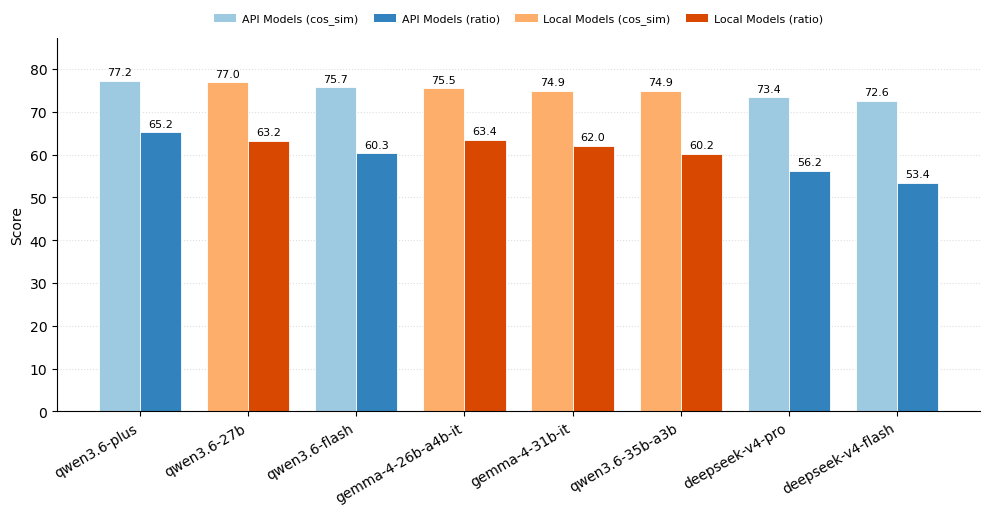

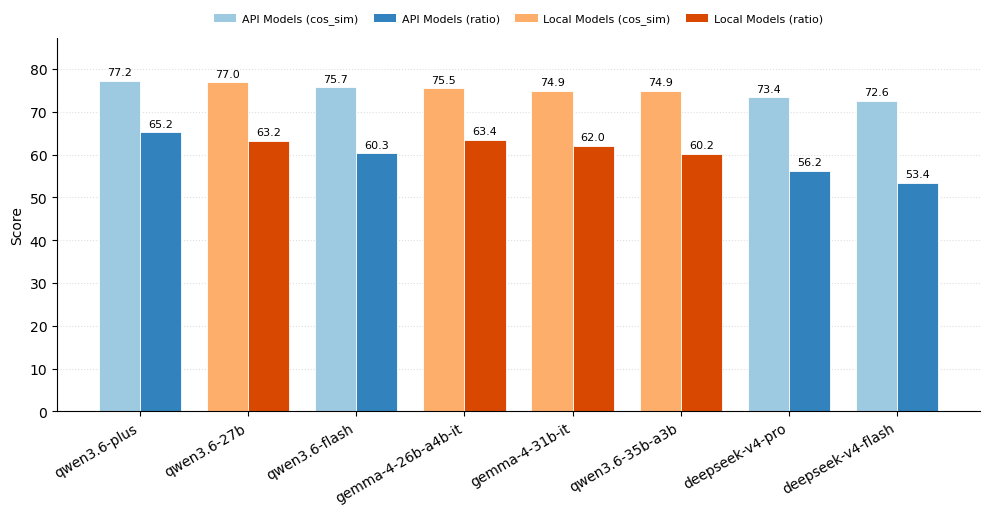

In [11]:
fig = make_fig8(cos, rat, model_order)
fig.savefig(Path(OUTPUT_DIR) / "fig8_model_comparison.png", dpi=300, bbox_inches="tight")
fig.savefig(Path(OUTPUT_DIR) / "fig8_model_comparison.pdf", bbox_inches="tight")
fig

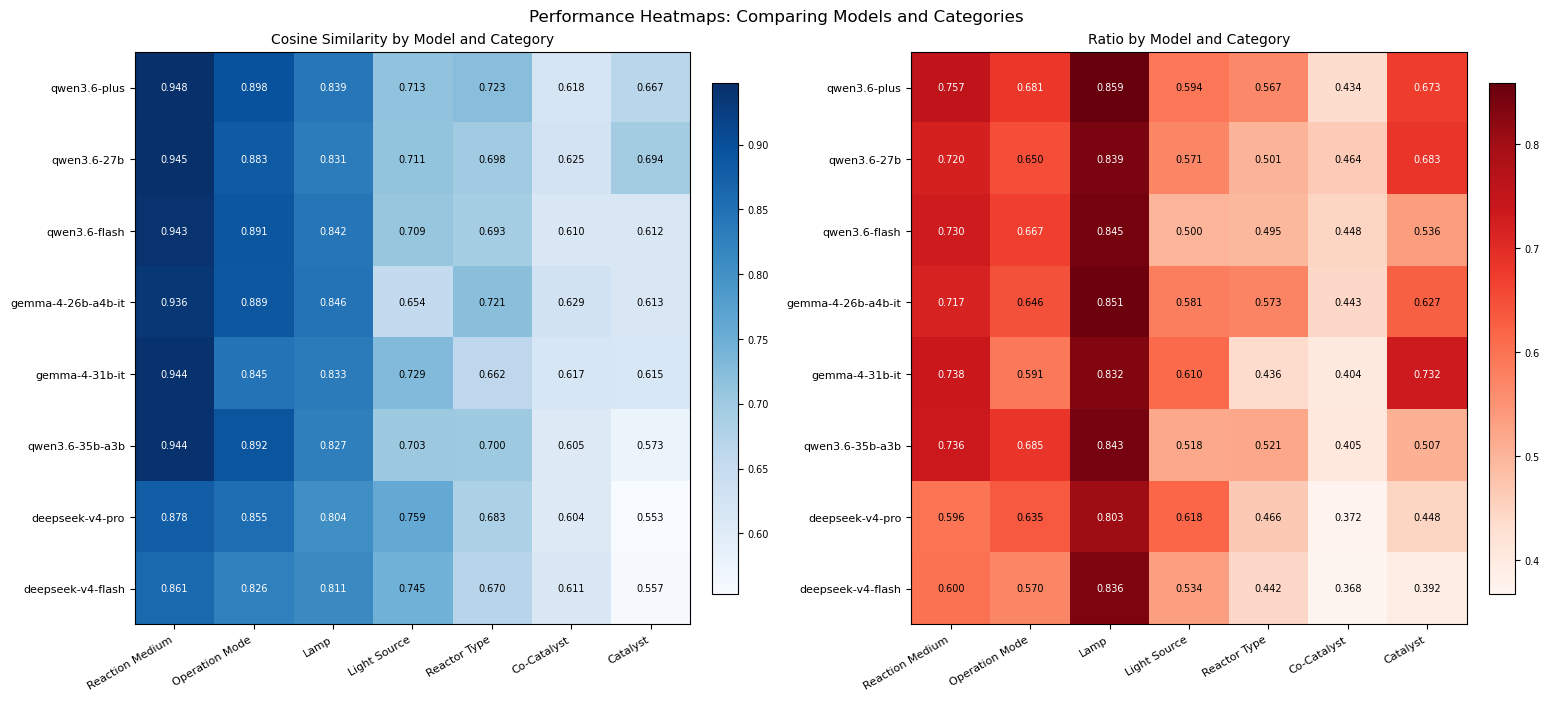

In [9]:
def make_fig9(cos, rat, mo, co):
    C = np.array([[cos[m][c] for c in co] for m in mo])
    R = np.array([[rat[m][c] for c in co] for m in mo])
    fig, axes = plt.subplots(1, 2, figsize=(max(12, 2.2 * len(co)), .55 * len(mo) + 2.5),
                             constrained_layout=True)
    for a, M, cmap, t in [(axes[0], C, "Blues", "Cosine Similarity by Model and Category"),
                          (axes[1], R, "Reds", "Ratio by Model and Category")]:
        f = M[np.isfinite(M)]; vmin, vmax = (f.min(), f.max()) if f.size else (0, 1)
        im = a.imshow(M, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)
        a.set_xticks(range(len(co))); a.set_xticklabels([DISPLAY[c] for c in co], rotation=30, ha="right", fontsize=8)
        a.set_yticks(range(len(mo))); a.set_yticklabels([pretty(m) for m in mo], fontsize=8)
        a.set_title(t, fontsize=10)
        thr = vmin + .6 * (vmax - vmin)
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                v = M[i, j]
                a.text(j, i, "-" if v != v else f"{v:.3f}", ha="center", va="center",
                       fontsize=7, color=("white" if v == v and v >= thr else ("0.4" if v != v else "black")))
        fig.colorbar(im, ax=a, fraction=.046, pad=.04).ax.tick_params(labelsize=7)
    fig.suptitle("Performance Heatmaps: Comparing Models and Categories", fontsize=12)
    return fig

fig = make_fig9(cos, rat, model_order, cat_order)
fig.savefig(Path(OUTPUT_DIR) / "fig9_heatmaps.png", dpi=300, bbox_inches="tight")
fig.savefig(Path(OUTPUT_DIR) / "fig9_heatmaps.pdf", bbox_inches="tight")
# fig